#  MISIÓN 1: Caza del Cliente Desertor (Churn)

##  1. Definición del Problema Comercial
En Olist, la deserción de clientes (Churn) es silenciosa. No existen suscripciones mensuales que se cancelen; un cliente simplemente compra y no vuelve a interactuar con la plataforma.

**Regla de Negocio:**
Definimos que un cliente entra en **Churn (1)** si han transcurrido más de **90 días** desde su última compra hasta la fecha de cierre de registro del dataset. De lo contrario, se clasifica como **No Churn (0)**.

---

##  2. Análisis Exploratorio de Datos (EDA) y Justificación de Variables

Para entrenar un modelo que prediga si un cliente desertará, analizamos las siguientes variables de su comportamiento histórico:

1. **`total_compras`:** Refleja la frecuencia real del cliente (medido con órdenes únicas `nunique`).
2. **`monto_total_gastado`:** Mide el valor monetario del cliente para la plataforma.
3. **`promedio_flete_pagado`:** Captura el impacto económico del envío, un punto crítico de insatisfacción en e-commerce.
4. **`promedio_review_score`:** Indicador directo de satisfacción. Las calificaciones nulas se imputan con la media global de la plataforma para mantener una postura neutra.
5. **`dias_historicos_actividad`:** Antigüedad operativa ($ \text{Última compra} - \text{Primera compra} $).
6. **`items_por_orden`:** Volumen de la cesta promedio.
7. **`ratio_flete_precio`:** Sensibilidad al precio del envío ($ \text{Flete} / \text{Monto Total} $).

>  **Exclusión Estratégica (Data Leakage & Geolocalización):**
> - Excluimos explícitamente la variable `dias_inactivo` de la matriz $X$, ya que causaría **Data Leakage** (fuga de datos) al estar matemáticamente vinculada a la definición de Churn.
> - Omitimos los códigos postales específicos de geolocalización para evitar **Alta Cardinalidad** y prevenir overfitting, capturando el efecto de la distancia a través del costo del flete.

In [2]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# 1. Cargar datos
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
order_reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")

# 2. Filtrar órdenes entregadas y convertir fechas
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders_valid = orders[orders['order_status'] == 'delivered'].copy()

# 3. Unir tablas principales
df = orders_valid.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
df = df.merge(order_items[['order_id', 'order_item_id', 'price', 'freight_value']], on='order_id', how='left')
df = df.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

# 4. Agrupar por cliente único y calcular métricas
df_churn = df.groupby('customer_unique_id').agg(
    primera_compra=('order_purchase_timestamp', 'min'),
    ultima_compra=('order_purchase_timestamp', 'max'),
    total_compras=('order_id', 'nunique'),
    total_articulos=('order_item_id', 'count'),
    monto_total_gastado=('price', 'sum'),
    promedio_flete_pagado=('freight_value', 'mean'),
    promedio_review_score=('review_score', 'mean')
).reset_index()

# 5. Feature Engineering
df_churn['dias_historicos_actividad'] = (df_churn['ultima_compra'] - df_churn['primera_compra']).dt.days
df_churn['items_por_orden'] = df_churn['total_articulos'] / df_churn['total_compras']
df_churn['ratio_flete_precio'] = df_churn['promedio_flete_pagado'] / (df_churn['monto_total_gastado'] + 0.001)

# 6. Definir la Variable Objetivo (y)
fecha_referencia = df['order_purchase_timestamp'].max()
dias_inactivo = (fecha_referencia - df_churn['ultima_compra']).dt.days
df_churn['churn'] = (dias_inactivo > 90).astype(int)

# 7. Separar X e y con Imputación Neutra
media_review_global = df['review_score'].mean()
features_cols = [
    'total_compras', 'monto_total_gastado', 'promedio_flete_pagado', 
    'promedio_review_score', 'dias_historicos_actividad', 
    'items_por_orden', 'ratio_flete_precio'
]

X = df_churn[features_cols].copy()
X['promedio_review_score'] = X['promedio_review_score'].fillna(media_review_global)
y = df_churn['churn']

# 8. Train/Test Split con Estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## ⚙️ 3. Entrenamiento y Comparativa de Modelos en Pipeline

Evaluamos tres modelos del arsenal algorítmico utilizando **Pipelines** de `scikit-learn` para garantizar que la estandarización de variables (`StandardScaler`) no filtre datos entre Train y Test.

In [3]:
pipelines = {
    ' Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),
    ' Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ]),
    ' Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    ' SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(class_weight='balanced', random_state=42))
    ]),
    ' kNN': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    ' Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB())
    ])
}

# 2. Entrenamiento y Evaluación Sistemática
resultados_resumen = []

for nombre, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print(f"\n==================== {nombre.upper()} ====================")
    print(classification_report(y_test, y_pred))


====================  DECISION TREE ====================
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      3718
           1       0.92      0.92      0.92     14954

    accuracy                           0.87     18672
   macro avg       0.80      0.81      0.80     18672
weighted avg       0.88      0.87      0.87     18672


====================  RANDOM FOREST ====================
              precision    recall  f1-score   support

           0       0.64      0.68      0.66      3718
           1       0.92      0.90      0.91     14954

    accuracy                           0.86     18672
   macro avg       0.78      0.79      0.79     18672
weighted avg       0.86      0.86      0.86     18672


====================  GRADIENT BOOSTING ====================
              precision    recall  f1-score   support

           0       0.81      0.11      0.20      3718
           1       0.82      0.99      0.90     14954

    

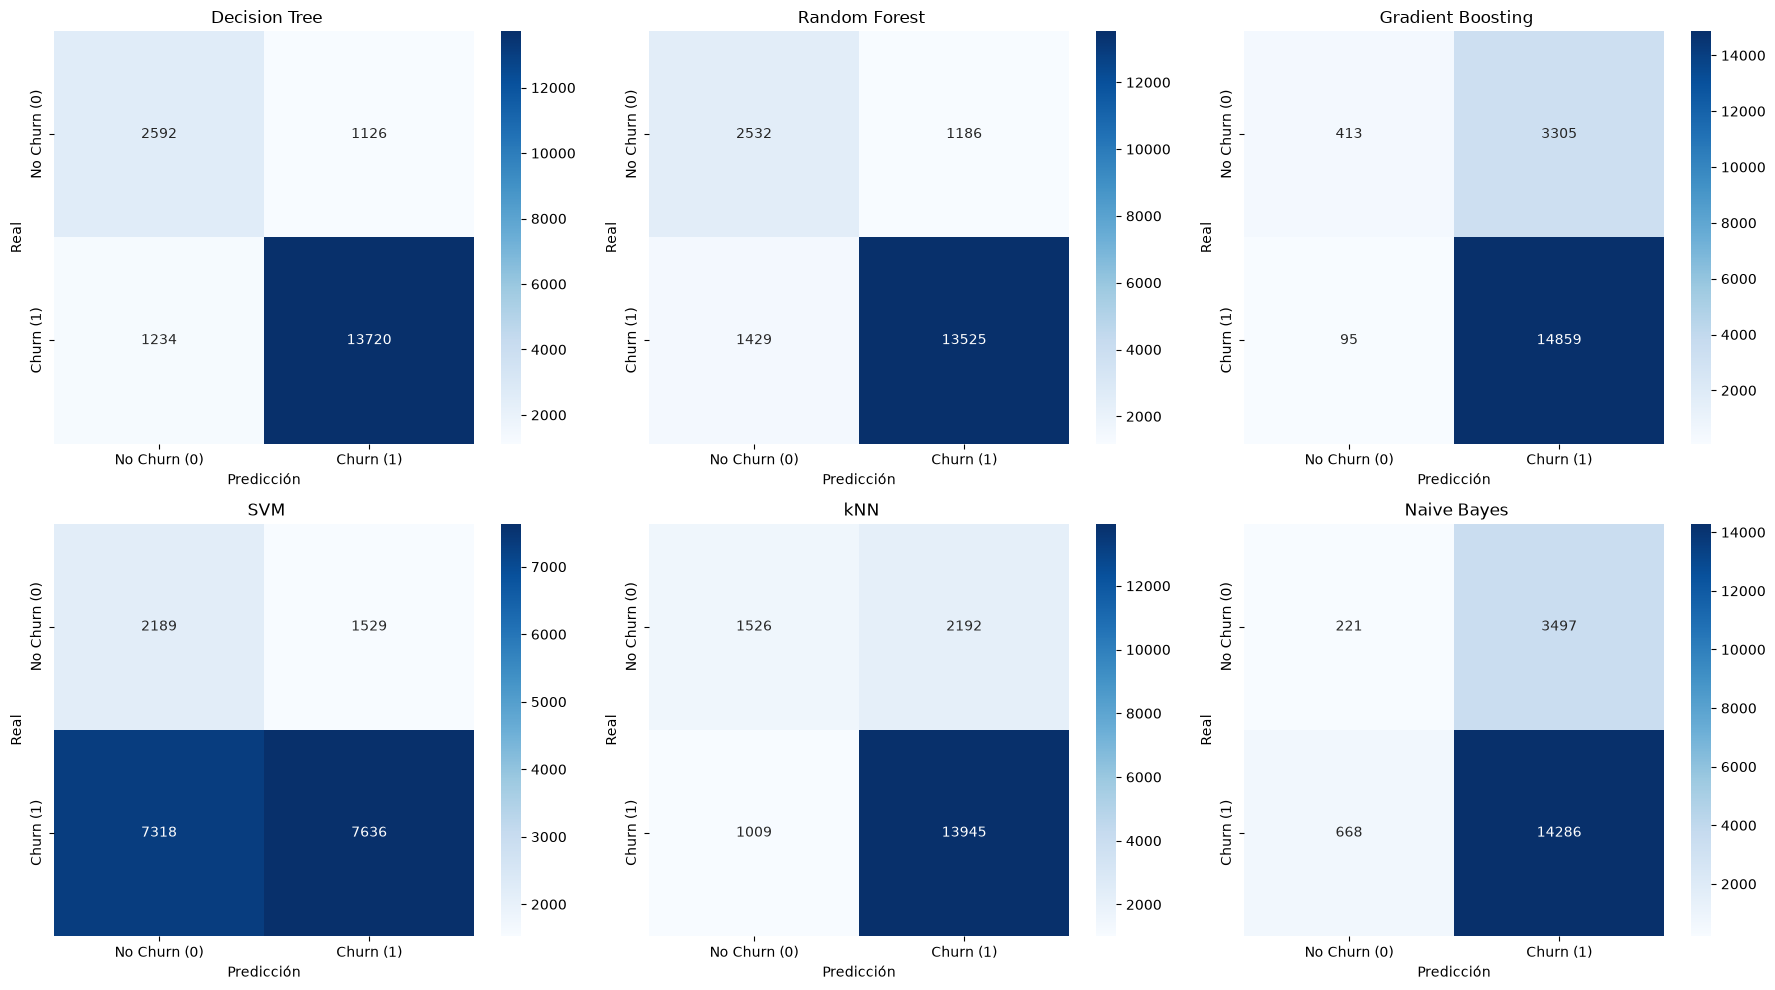

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (nombre, pipe) in enumerate(pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn (0)', 'Churn (1)'],
                yticklabels=['No Churn (0)', 'Churn (1)'])
    axes[i].set_title(f'{nombre}')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

## 🧪 4. PRUEBA INDIVIDUAL

In [12]:
# 1. Seleccionar modelo y cliente al azar de Test
modelo_elegido = pipelines[' Random Forest']
indice_aleatorio = np.random.choice(X_test.index)
cliente_id = df_churn.loc[indice_aleatorio, 'customer_unique_id']

# 2. Extraer datos y realizar predicción
datos_cliente = X_test.loc[[indice_aleatorio]]
realidad = y_test.loc[indice_aleatorio]

prediccion = modelo_elegido.predict(datos_cliente)[0]
probabilidades = modelo_elegido.predict_proba(datos_cliente)[0]

# 3. Construir Tabla de Diagnóstico Individual
reporte_cliente = pd.DataFrame({
    'Métrica / Campo': [
        'ID Cliente',
        'Estado Real en Dataset',
        'Diagnóstico Predicho',
        'Probabilidad No Churn (0)',
        'Probabilidad Churn (1)',
        'Resultado de Evaluación'
    ],
    'Valor Evaluado': [
        cliente_id,
        'Desertor (1)' if realidad == 1 else 'Activo (0)',
        '🔴 "Se va"' if prediccion == 1 else '🟢 "Se queda... por ahora"',
        f"{probabilidades[0]*100:.1f}%",
        f"{probabilidades[1]*100:.1f}%",
        '✅ Acierto Correcto' if prediccion == realidad else '❌ Diagnóstico Erróneo'
    ]
})

print("="*60)
print(f"📋 REPORTE DE EVALUACIÓN INDIVIDUAL DE CLIENTE")
print("="*60)
print(reporte_cliente.to_string(index=False))
print("="*60)

📋 REPORTE DE EVALUACIÓN INDIVIDUAL DE CLIENTE
          Métrica / Campo                   Valor Evaluado
               ID Cliente 0ee369ad34ccebb65f036d062acb7349
   Estado Real en Dataset                     Desertor (1)
     Diagnóstico Predicho                        🔴 "Se va"
Probabilidad No Churn (0)                             0.0%
   Probabilidad Churn (1)                           100.0%
  Resultado de Evaluación               ✅ Acierto Correcto


## 5. Diagnóstico de Overfitting / Underfitting

Al ser un problema supervisado con `y` conocida, el diagnóstico compara el desempeño de cada
pipeline ya entrenado en `X_train`/`y_train` contra su desempeño en `X_test`/`y_test`. Se usan
`accuracy` y `F1 macro` (esta última pondera igual ambas clases, relevante porque el churn está
desbalanceado). Una brecha amplia entre train y test indica sobreajuste; un desempeño bajo en ambos
indica subajuste. Se complementa con validación cruzada de 5 folds sobre el modelo con mejor
resultado, para verificar que su desempeño no dependa de una partición particular de los datos.

,Modelo,Accuracy Train,Accuracy Test,Brecha Accuracy,F1 Train,F1 Test,Brecha F1
1,Random Forest,0.983,0.860,0.123,0.974,0.786,0.188
0,Decision Tree,0.987,0.874,0.113,0.979,0.804,0.175
4,kNN,0.878,0.829,0.049,0.782,0.693,0.090
3,SVM,0.530,0.526,0.004,0.485,0.482,0.003
5,Naive Bayes,0.777,0.777,-0.000,0.486,0.484,0.001
2,Gradient Boosting,0.817,0.818,-0.001,0.544,0.546,-0.002


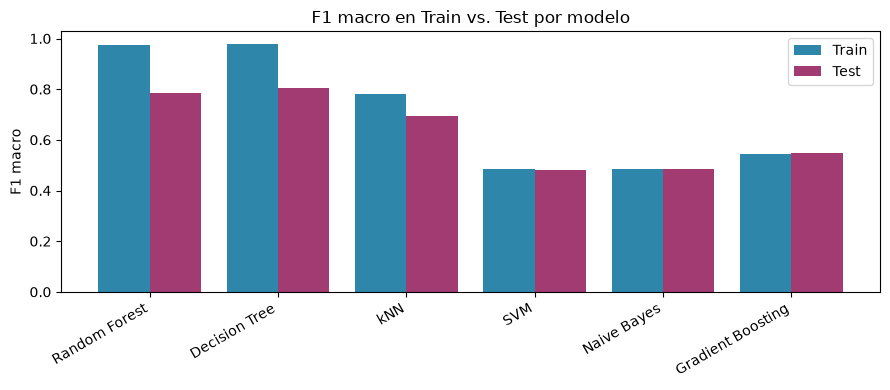

Modelo evaluado:  Decision Tree
F1 macro por fold: [0.792 0.792 0.789 0.79  0.799]
Media: 0.792  |  Desvío estándar: 0.003


In [13]:
# ==============================================================================
# 4.1 BRECHA TRAIN VS. TEST POR MODELO
# ==============================================================================
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

diagnostico = []
for nombre, pipe in pipelines.items():
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    acc_test  = accuracy_score(y_test, pipe.predict(X_test))
    f1_train  = f1_score(y_train, pipe.predict(X_train), average="macro")
    f1_test   = f1_score(y_test, pipe.predict(X_test), average="macro")

    diagnostico.append({
        "Modelo": nombre,
        "Accuracy Train": acc_train, "Accuracy Test": acc_test,
        "Brecha Accuracy": acc_train - acc_test,
        "F1 Train": f1_train, "F1 Test": f1_test,
        "Brecha F1": f1_train - f1_test,
    })

df_diag = pd.DataFrame(diagnostico).sort_values("Brecha F1", ascending=False)
display(df_diag.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(df_diag))
ax.bar(x - 0.2, df_diag["F1 Train"], width=0.4, label="Train", color="#2E86AB")
ax.bar(x + 0.2, df_diag["F1 Test"], width=0.4, label="Test", color="#A23B72")
ax.set_xticks(x)
ax.set_xticklabels(df_diag["Modelo"], rotation=30, ha="right")
ax.set_ylabel("F1 macro")
ax.set_title("F1 macro en Train vs. Test por modelo")
ax.legend()
plt.tight_layout()
plt.show()

# Validación cruzada del modelo con mayor F1 en test, para confirmar estabilidad
mejor_modelo = df_diag.sort_values("F1 Test", ascending=False).iloc[0]["Modelo"]
cv_scores = cross_val_score(pipelines[mejor_modelo], X_train, y_train, cv=5, scoring="f1_macro")
print(f"Modelo evaluado: {mejor_modelo}")
print(f"F1 macro por fold: {np.round(cv_scores, 3)}")
print(f"Media: {cv_scores.mean():.3f}  |  Desvío estándar: {cv_scores.std():.3f}")